In [3]:
import os
import glob
import re
import requests
import pandas as pd

# 1. הנתיב לתיקיית התמונות שלך
root_folder = r"/home/jonzy/python/תיקייה לפרוייקט גמר/dashfarmboardtrue/Students data/Students data"

# סריקת כל קבצי ה-NDVI
search_pattern = os.path.join(root_folder, "**", "*ndvi*.tiff")
tiff_files = glob.glob(search_pattern, recursive=True)

print(f"שלב 1: מצאתי {len(tiff_files)} תמונות. אוסף תאריכים...")

# 2. איסוף כל התאריכים הייחודיים מתוך שמות הקבצים
unique_dates = set()
for file_path in tiff_files:
    filename = os.path.basename(file_path)
    date_match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
    if date_match:
        unique_dates.add(date_match.group(0))

if not unique_dates:
    print("⚠️ לא מצאתי תאריכים בתמונות!")
else:
    # מציאת התאריך הראשון והאחרון כדי למשוך את כל הטווח מה-API במכה אחת
    min_date = min(unique_dates)
    max_date = max(unique_dates)
    print(f"מושך נתוני מזג אוויר מ-{min_date} עד {max_date}...")

    # 3. קואורדינטות של החווה (שים לב: כרגע שמתי פתח תקווה/מרכז כברירת מחדל)
    # **חשוב: שנה את המספרים האלה למיקום האמיתי של החלקות שלך כדי לקבל טמפרטורה מדויקת!**
    LATITUDE = 32.08
    LONGITUDE = 34.88

    # פנייה ל-API של מזג האוויר (Open-Meteo Archive)
    api_url = f"https://archive-api.open-meteo.com/v1/archive?latitude={LATITUDE}&longitude={LONGITUDE}&start_date={min_date}&end_date={max_date}&daily=temperature_2m_mean&timezone=auto"
    
    response = requests.get(api_url)
    
    if response.status_code == 200:
        weather_data = response.json()
        
        # 4. המרה לטבלה וסינון רק של התאריכים שיש לנו עבורם תמונות
        df_weather = pd.DataFrame({
            "Date": weather_data["daily"]["time"],
            "Temperature": weather_data["daily"]["temperature_2m_mean"]
        })
        
        # שומרים רק את הימים שבהם צולמה תמונה
        df_weather = df_weather[df_weather["Date"].isin(unique_dates)]
        
        # 5. יצירת קובץ ה-CSV
        csv_filename = "farm_temperatures.csv"
        df_weather.to_csv(csv_filename, index=False)
        print(f"✅ הצלחה! קובץ '{csv_filename}' נוצר ושמר בתוכו את הטמפרטורות.")
        print(df_weather.head())
    else:
        print(f"⚠️ שגיאה במשיכת הנתונים מה-API: {response.status_code}")

שלב 1: מצאתי 45 תמונות. אוסף תאריכים...
מושך נתוני מזג אוויר מ-2025-11-30 עד 2026-01-23...
✅ הצלחה! קובץ 'farm_temperatures.csv' נוצר ושמר בתוכו את הטמפרטורות.
          Date  Temperature
0   2025-11-30         18.8
5   2025-12-05         21.4
7   2025-12-07         16.8
10  2025-12-10         13.8
15  2025-12-15         13.5


✅ קובץ ה-CSV נטען בהצלחה!
מנתח את תמונות הלוויין ומצליב טמפרטורות...

הושלם החיבור! הנה 5 השורות הראשונות של הנתונים האמיתיים:
         Date  Mean_NDVI  Temperature                            Farm_Name
0  2026-01-11   0.115050         13.6  Florian_la_palmeraie_satellite_data
1  2026-01-02   0.260859         13.1  Florian_la_palmeraie_satellite_data
2  2026-01-09   0.545107         15.1  Florian_la_palmeraie_satellite_data
3  2026-01-14   0.704594         13.6  Florian_la_palmeraie_satellite_data
4  2026-01-17   0.955156         11.9  Florian_la_palmeraie_satellite_data


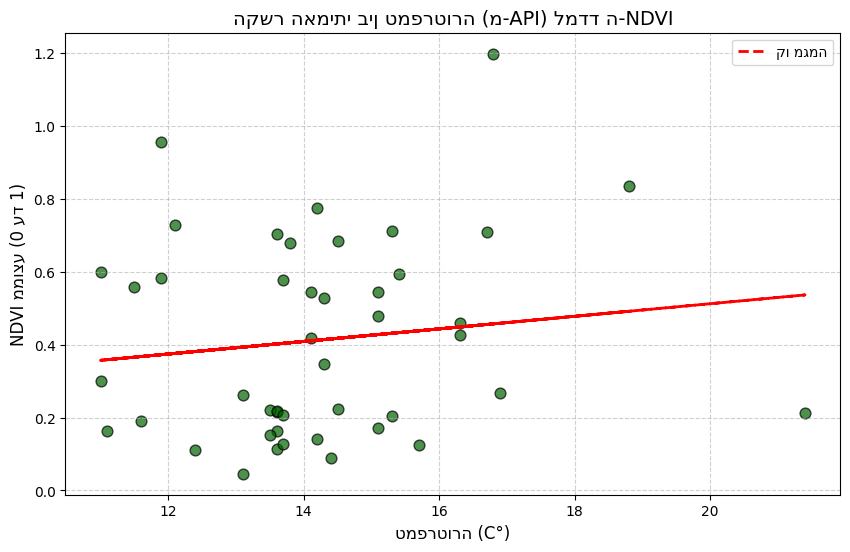

In [ ]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

# 1. טעינת קובץ ה-CSV שיצרנו הרגע
try:
    df_temps = pd.read_csv("farm_temperatures.csv")
    # הופכים את זה למילון מהיר שבו התאריך הוא המפתח והטמפרטורה היא הערך
    temp_dict = dict(zip(df_temps["Date"], df_temps["Temperature"]))
    print("✅ קובץ ה-CSV נטען בהצלחה!")
except FileNotFoundError:
    print("⚠️ לא מצאתי את הקובץ farm_temperatures.csv. ודא שחלק 1 רץ בהצלחה.")
    temp_dict = {}

data_records = []

# 2. מעבר על התמונות וחיבור הנתונים
print("מנתח את תמונות הלוויין ומצליב טמפרטורות...")
for file_path in tiff_files:
    filename = os.path.basename(file_path)
    date_match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
    
    if date_match:
        date_str = date_match.group(0)
        
        # בודקים אם יש לנו טמפרטורה לאותו תאריך מה-CSV
        if date_str in temp_dict:
            # קוראים את ה-TIFF ומחשבים NDVI ממוצע
            image_array = tiff.imread(file_path)
            mean_ndvi = np.nanmean(image_array)
            
            data_records.append({
                "Date": date_str,
                "Mean_NDVI": mean_ndvi,
                "Temperature": temp_dict[date_str],
                "Farm_Name": os.path.basename(os.path.dirname(file_path))
            })

# 3. יצירת הטבלה הסופית והצגת הגרף
if len(data_records) > 0:
    df_final = pd.DataFrame(data_records)
    df_final = df_final.dropna(subset=['Temperature', 'Mean_NDVI'])
    
    print(f"\nהושלם החיבור! הנה 5 השורות הראשונות של הנתונים האמיתיים:")
    print(df_final.head())

    # ציור הגרף
    plt.figure(figsize=(10, 6))
    plt.scatter(df_final['Temperature'], df_final['Mean_NDVI'], color='darkgreen', alpha=0.7, edgecolors='black', s=60)
    plt.title('הקשר האמיתי בין טמפרטורה (מ-API) למדד ה-NDVI', fontsize=14)
    plt.xlabel('טמפרטורה (C°)', fontsize=12)
    plt.ylabel('NDVI ממוצע (0 עד 1)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # הוספת קו מגמה 
    if len(df_final) > 1:
        z = np.polyfit(df_final['Temperature'], df_final['Mean_NDVI'], 1)
        p = np.poly1d(z)
        plt.plot(df_final['Temperature'], p(df_final['Temperature']), "r--", linewidth=2, label="קו מגמה")
        plt.legend()
        
    plt.show()
else:
    print("⚠️ לא הצלחתי לחבר בין התמונות לטמפרטורות.")